In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Pradeep\udemy Final\PNL_Analysis\data\pnl_risk_data.csv")

df.head()
#print(df.shape)
#print(df.columns)

,DV01,Vega,Gamma,MarketMove,VaR,ResidualPnL,TradeCount,ReconBreak
0,209015,75725,2581,0.313346,277401,99994,315,0
1,244330,121912,14662,1.014219,298102,14067,882,1
2,96368,124632,19813,1.439022,286696,75523,501,1
3,207934,123799,1837,0.964782,178260,43989,152,0
4,154226,57149,2576,1.458294,326062,87380,666,1


In [3]:
df.describe()

,DV01,Vega,Gamma,MarketMove,VaR,ResidualPnL,TradeCount,ReconBreak
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,150562.559400,80578.608600,15462.31460,0.804607,350258.027800,50371.00200,550.690000,0.507600
std,57773.550846,40590.317796,8377.32235,0.404177,145189.843831,28531.47723,260.180073,0.499992
min,50023.000000,10006.000000,1000.00000,0.100322,100155.000000,1026.00000,100.000000,0.000000
25%,99981.750000,44683.500000,8272.00000,0.450797,224287.500000,25554.00000,320.000000,0.000000
50%,151642.500000,80514.500000,15377.00000,0.822157,347714.500000,50330.00000,554.000000,1.000000
75%,200500.750000,116385.500000,22775.25000,1.153610,477065.750000,75002.00000,776.000000,1.000000
max,249924.000000,149933.000000,29996.00000,1.499826,599986.000000,99999.00000,999.000000,1.000000


In [4]:
df.isnull().sum()

DV01           0
Vega           0
Gamma          0
MarketMove     0
VaR            0
ResidualPnL    0
TradeCount     0
ReconBreak     0
dtype: int64

In [5]:
df[['DV01', 'Vega']].isnull().sum()
#df[['DV01']].isnull().sum()

DV01    0
Vega    0
dtype: int64

In [6]:
#Show Only Rows Where Any of These Columns Are NULL
df[df[['DV01', 'Vega']].isnull().any(axis=1)]
df[df[['DV01', 'Vega']].isnull().any(axis=1)]

,DV01,Vega,Gamma,MarketMove,VaR,ResidualPnL,TradeCount,ReconBreak


In [7]:
#Show Rows Where All Specified Columns Are NULL
df[df[['DV01', 'Vega']].isnull().all(axis=1)]

,DV01,Vega,Gamma,MarketMove,VaR,ResidualPnL,TradeCount,ReconBreak


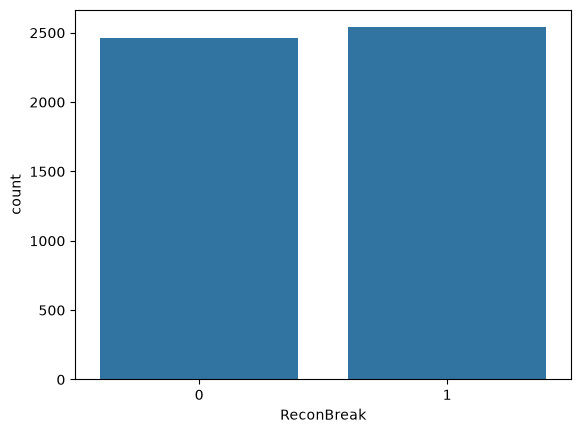

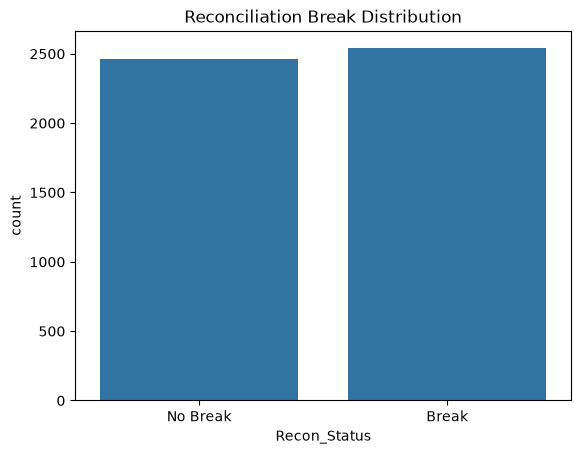

In [8]:
#Step 4: Exploratory Data Analysis (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ReconBreak',data=df)

plt.show()

#sns.boxplot(x='ReconBreak', data=df)
#plt.show()

df['Recon_Status'] = df['ReconBreak'].map({
    0: 'No Break',
    1: 'Break'
})

sns.countplot(x='Recon_Status', data=df)
plt.title('Reconciliation Break Distribution')
plt.show()

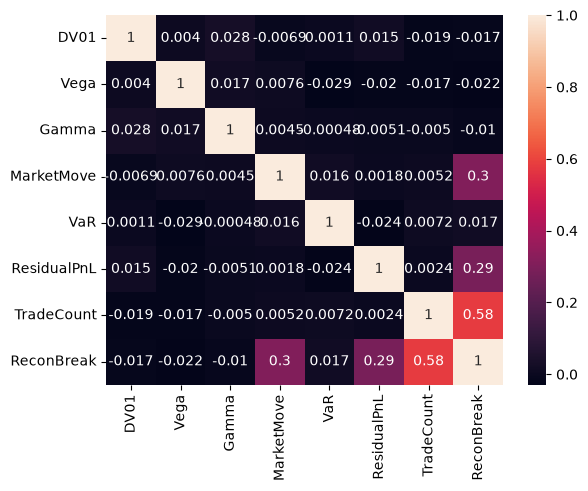

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DV01          5000 non-null   int64  
 1   Vega          5000 non-null   int64  
 2   Gamma         5000 non-null   int64  
 3   MarketMove    5000 non-null   float64
 4   VaR           5000 non-null   int64  
 5   ResidualPnL   5000 non-null   int64  
 6   TradeCount    5000 non-null   int64  
 7   ReconBreak    5000 non-null   int64  
 8   Recon_Status  5000 non-null   str    
dtypes: float64(1), int64(7), str(1)
memory usage: 351.7 KB


In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

df.info()

In [10]:
#X = df.drop('ReconBreak', axis=1)
X = df.drop(columns=['ReconBreak', 'Recon_Status'])

   #df.drop(columns=['ReconBreak'])
y = df['ReconBreak']

display(X)
display(y)

,DV01,Vega,Gamma,MarketMove,VaR,ResidualPnL,TradeCount
0,209015,75725,2581,0.313346,277401,99994,315
1,244330,121912,14662,1.014219,298102,14067,882
2,96368,124632,19813,1.439022,286696,75523,501
3,207934,123799,1837,0.964782,178260,43989,152
4,154226,57149,2576,1.458294,326062,87380,666
...,...,...,...,...,...,...,...
4995,224834,148097,21294,0.240971,175996,63265,277
4996,112566,134109,16522,1.018008,553627,14209,145
4997,78799,14031,29634,0.735675,232284,12870,913
4998,221547,13544,24242,0.160743,591241,25934,111


0       0
1       1
2       1
3       0
4       1
       ..
4995    0
4996    0
4997    1
4998    0
4999    0
Name: ReconBreak, Length: 5000, dtype: int64

In [11]:
###Train/Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [12]:
print(type(y))
print(y.shape)
print(y.head())

<class 'pandas.Series'>
(5000,)
0    0
1    1
2    1
3    0
4    1
Name: ReconBreak, dtype: int64


In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(
X_train,
y_train
)
lr_pred = lr.predict(X_test)
train_accuracy = lr.score(X_train, y_train)
test_accuracy = lr.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.7855
Testing Accuracy  : 0.79


c:\Pradeep\udemy Final\python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(
X_train,
y_train
)
dt_pred = dt.predict(X_test)
train_accuracy = dt.score(X_train, y_train)
test_accuracy = dt.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy  : 1.0


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy  : 1.0


In [16]:
results = {

'Logistic':lr.score(X_test,y_test),

'DecisionTree':dt.score(X_test,y_test),

'RandomForest':rf.score(X_test,y_test)

}

results

{'Logistic': 0.79, 'DecisionTree': 1.0, 'RandomForest': 1.0}

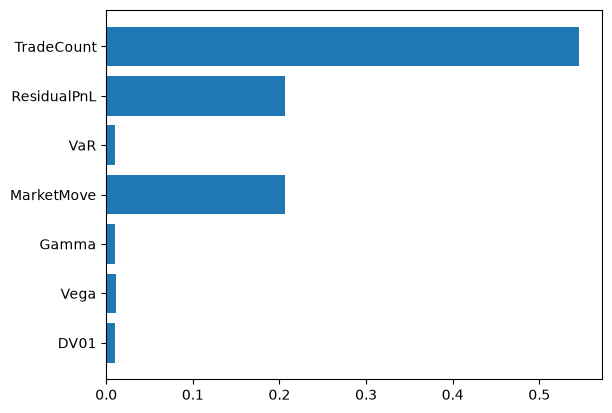

In [17]:
import matplotlib.pyplot as plt

plt.barh(

X.columns,

rf.feature_importances_

)

plt.show()

In [37]:
#model Evaluation

from sklearn.metrics import accuracy_score

accuracy_score(y_test,lr_pred)
accuracy_score(y_test,rf_pred)
accuracy_score(y_test,dt_pred)

1.0

In [38]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,lr_pred)
confusion_matrix(y_test,rf_pred)
confusion_matrix(y_test,dt_pred)


array([[495,   0],
       [  0, 505]])

In [40]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,lr_pred))
print(classification_report(y_test,rf_pred))
print(classification_report(y_test,dt_pred))



              precision    recall  f1-score   support

           0       0.84      0.72      0.77       495
           1       0.76      0.86      0.81       505

    accuracy                           0.79      1000
   macro avg       0.80      0.79      0.79      1000
weighted avg       0.80      0.79      0.79      1000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       495
           1       1.00      1.00      1.00       505

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       495
           1       1.00      1.00      1.00       505

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [19]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({

'Feature': X.columns,

'Importance':
rf.feature_importances_

})

In [20]:
importance = importance.sort_values(
'Importance',
ascending=False
)

importance

,Feature,Importance
6,TradeCount,0.545365
5,ResidualPnL,0.206825
3,MarketMove,0.206422
1,Vega,0.011287
0,DV01,0.010373
2,Gamma,0.010132
4,VaR,0.009596


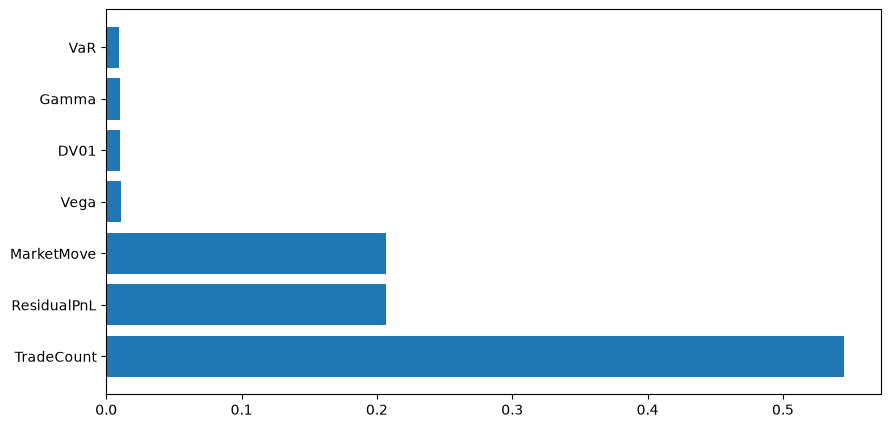

In [21]:
plt.figure(figsize=(10,5))

plt.barh(

importance['Feature'],

importance['Importance']

)

plt.show()

In [22]:
from sklearn.metrics import classification_report

In [25]:
print(

classification_report(
y_test,
y_pred
)

)

NameError: name 'y_pred' is not defined